# Projeto - Robô seguido de parede

**Objetivo:** criar uma rede MLP que consiga classificar corretamente qual é a ação que deve ser tomada para que o robô permanece seguindo uma parede.


**Proposta futura:** Criar uma rede MLP para obter a função de custo para que o robô possa se mover de maneira autônoma em um ambiente.

## Libraries

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1788719872.691619  817855 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788719872.950468  817855 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data extract

In [14]:
# Carrega os dados gerados
df = pd.read_csv("project-robotics/controllers/data_collector/dataset.csv")

In [15]:
df.head()

,ps0,ps1,ps2,ps3,ps4,ps5,ps6,ps7,ps0_norm,ps1_norm,ps2_norm,ps3_norm,ps4_norm,ps5_norm,ps6_norm,ps7_norm,distance_min,cost,collision
0,160.974961,0.000000,0.000000,0.000000,114.314374,365.380118,123.662051,0.333538,0.039301,0.000000,0.000000,0.000000,0.027909,0.089204,0.030191,0.000081,0.114915,0.562945,0
1,0.000000,0.000000,4.798804,2.657663,0.000000,0.000000,523.178883,0.000000,0.000000,0.000000,0.001172,0.000649,0.000000,0.000000,0.127729,0.000000,0.114915,0.562945,0
2,420.242790,10.749778,0.000000,1.577199,119.365386,37.293142,0.000000,136.692342,0.102598,0.002624,0.000000,0.000385,0.029142,0.009105,0.000000,0.033372,0.114915,0.562945,0
3,9.969915,382.151786,94.616822,73.806795,104.009311,0.000000,25.706470,0.000000,0.002434,0.093299,0.023100,0.018019,0.025393,0.000000,0.006276,0.000000,0.114915,0.562945,0
4,66.838899,95.550412,347.849033,45.129778,45.578586,77.778235,103.155422,43.571777,0.016318,0.023328,0.084924,0.011018,0.011128,0.018989,0.025184,0.010638,0.114915,0.562945,0


In [16]:
df.describe()

,ps0,ps1,ps2,ps3,ps4,ps5,ps6,ps7,ps0_norm,ps1_norm,ps2_norm,ps3_norm,ps4_norm,ps5_norm,ps6_norm,ps7_norm,distance_min,cost,collision
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,180.415099,184.985315,171.638616,191.643719,187.007648,172.027476,187.645472,176.830064,0.044047,0.045162,0.041904,0.046788,0.045656,0.041999,0.045812,0.043171,0.067023,0.730298,0.096500
std,461.548969,489.630426,440.496947,503.325860,493.037580,440.475205,492.850540,453.846872,0.112683,0.119539,0.107543,0.122882,0.120371,0.107538,0.120325,0.110802,0.046968,0.163101,0.295285
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.019813,0.383250,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.028680,0.600014,0.000000
50%,17.727493,18.706286,18.364704,17.209038,16.273011,17.142724,17.244759,16.997092,0.004328,0.004567,0.004484,0.004201,0.003973,0.004185,0.004210,0.004150,0.070205,0.703967,0.000000
75%,93.036717,92.365344,91.201288,91.813064,90.733927,91.258983,93.948295,90.180478,0.022714,0.022550,0.022266,0.022415,0.022152,0.022280,0.022937,0.022017,0.102161,0.866406,0.000000
max,4096.000000,3975.988919,4038.074613,4051.698031,4096.000000,3864.347437,3904.955443,3894.267299,1.000000,0.970700,0.985858,0.989184,1.000000,0.943444,0.953358,0.950749,0.191813,1.000000,1.000000


In [133]:
# criando as colunas
col = [f"sensor_{i}" for i in range(1, 25)] + ["acao"]

df = pd.read_csv(url, names=col)

df.head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,acao
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [134]:
df.describe()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sensor_1   5456 non-null   float64
 1   sensor_2   5456 non-null   float64
 2   sensor_3   5456 non-null   float64
 3   sensor_4   5456 non-null   float64
 4   sensor_5   5456 non-null   float64
 5   sensor_6   5456 non-null   float64
 6   sensor_7   5456 non-null   float64
 7   sensor_8   5456 non-null   float64
 8   sensor_9   5456 non-null   float64
 9   sensor_10  5456 non-null   float64
 10  sensor_11  5456 non-null   float64
 11  sensor_12  5456 non-null   float64
 12  sensor_13  5456 non-null   float64
 13  sensor_14  5456 non-null   float64
 14  sensor_15  5456 non-null   float64
 15  sensor_16  5456 non-null   float64
 16  sensor_17  5456 non-null   float64
 17  sensor_18  5456 non-null   float64
 18  sensor_19  5456 non-null   float64
 19  sensor_20  5456 non-null   float64
 20  sensor_21  5456 non

In [136]:
# Separa o X e o y bruto
X = df.drop(columns=["acao"])
y_raw = df["acao"].values

In [137]:
np.unique(y_raw)

array(['Move-Forward', 'Sharp-Right-Turn', 'Slight-Left-Turn',
       'Slight-Right-Turn'], dtype=object)

In [138]:
# Converte String para int
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)
classes = len(encoder.classes_)

classes

4

In [139]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sensor_1   5456 non-null   float64
 1   sensor_2   5456 non-null   float64
 2   sensor_3   5456 non-null   float64
 3   sensor_4   5456 non-null   float64
 4   sensor_5   5456 non-null   float64
 5   sensor_6   5456 non-null   float64
 6   sensor_7   5456 non-null   float64
 7   sensor_8   5456 non-null   float64
 8   sensor_9   5456 non-null   float64
 9   sensor_10  5456 non-null   float64
 10  sensor_11  5456 non-null   float64
 11  sensor_12  5456 non-null   float64
 12  sensor_13  5456 non-null   float64
 13  sensor_14  5456 non-null   float64
 14  sensor_15  5456 non-null   float64
 15  sensor_16  5456 non-null   float64
 16  sensor_17  5456 non-null   float64
 17  sensor_18  5456 non-null   float64
 18  sensor_19  5456 non-null   float64
 19  sensor_20  5456 non-null   float64
 20  sensor_21  5456 non

## Data transform

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
test_size=0.2, random_state=42, stratify=y)
# stratify obriga que o conjunto de Teste tenha exatamente a 
# mesma proporção de rótulos de cada classe que existe no dataset original 

print(f" Total de amostras: {len(X)}")

 Total de amostras: 5456


In [141]:
normalizer = StandardScaler()
X_train_scaled = normalizer.fit_transform(X_train)
X_test_scaled = normalizer.transform(X_test)

## Model

```cmd
"""
BatchNormalization(): Ele é uma camada que pega o resultado (a saída) dos neurônios da camada anterior
 e re-normaliza os números (centralizando em torno de zero) antes de passá-los 
 para a próxima camada.
"""

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(24,)), # 24 features

    #tf.keras.layers.Dense(128, activation="relu"),
    #tf.keras.layers.BatchNormalization(), 
    
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Dense(32, activation="relu"),
    
    tf.keras.layers.Dense(4, activation="softmax") # "multiclasses"
])
```

## Train

```cmd
# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# A escolha da função de perda depende inteiramente do formato dos seus rótulos (saídas esperadas) 
# e do objetivo matemático do problema.
"""
 - tf.keras.losses.SparseCategoricalCrossentropy()  # ideal para rótulos são inteiros 
 - tf.keras.losses.MeanSquaredError()  # problema de regressão
 - tf.keras.losses.CategoricalCrossentropy()  # quando tiver convertido os rótulos para o formato One-Hot Encoding (vetores binários)
"""

loss_func = tf.keras.losses.SparseCategoricalCrossentropy()

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

model.compile(optimizer=optimizer, loss=loss_func, metrics=["accuracy"]) # adição de métrica para compilar
```


```cmd
# Train'
history = model.fit(
    X_train_scaled, y_train, 
    epochs=300, 
    batch_size=32, 
    validation_split=0.1,
    callbacks=[early_stop], 
    verbose=1
)
```

```cmd
plt.figure(figsize=(5, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
#plt.yscale("log")
plt.xlabel("Época")
plt.legend(["Treino", "Validacao"])
```

In [169]:
"""
A palavra Dropout pode ser traduzida como "desistência" ou "descarte". Na prática, ela funciona da seguinte forma:

Desativação Aleatória: A cada iteração do treinamento (cada batch), a camada de Dropout "desliga" aleatoriamente uma porcentagem dos neurônios da camada anterior.

Exemplo: Se você usar Dropout(0.2), significa que 20% dos neurônios daquela camada serão ignorados naquela rodada de aprendizado.
Fim da Dependência (Co-adaptação): Como a rede neural nunca sabe quais neurônios estarão disponíveis na próxima rodada, ela não pode depender de apenas um ou dois neurônios específicos para tomar uma decisão.

Distribuição do Conhecimento: Isso força a rede a espalhar e distribuir o conhecimento por todos os neurônios, criando caminhos redundantes e tornando o modelo muito mais generalista e robusto.
"""


def best_train(X_train, y_train, param_grid, num_classes=4):
    """
    Busca exaustiva (Grid Search) para encontrar o melhor conjunto 
    de hiperparâmetros em uma rede neural MLP.
    """
    # 1. Cria todas as combinações possíveis a partir do dicionário
    keys = param_grid.keys()
    values = (param_grid[key] for key in keys)
    combinations = [dict(zip(keys, combination)) for combination in itertools.product(*values)]
    
    best_acc = 0.0
    best_params = None
    best_model = None
    best_history = None
    
    print(f"Iniciando Grid Search. Total de combinações a testar: {len(combinations)}\n")
    
    for i, params in enumerate(combinations):
        print(f"[{i+1}/{len(combinations)}] Testando: {params}")
        
        model = Sequential()

        # 1 camada oculta
        model.add(Dense(params['neurons_layer1'], activation='relu', input_shape=(X_train.shape[1],)))
        
        # Normalização em lote
        if params.get('use_batch_norm', False):
            model.add(tf.keras.layers.BatchNormalization())

        if params.get('dropout_rate', 0) > 0:
            model.add(Dropout(params['dropout_rate']))
        
        # 2 camada oculta
        if params.get('neurons_layer2', 0) > 0:

            model.add(Dense(params['neurons_layer2'], activation='relu'))

            # Normalização em lote na 2 camada
            if params.get('use_batch_norm', False):
                model.add(tf.keras.layers.BatchNormalization())

            if params.get('dropout_rate', 0) > 0:
                model.add(Dropout(params['dropout_rate']))
                
        # 3 Camada de saída
        model.add(Dense(num_classes, activation='softmax'))
        
        # Compila o modelo
        lr = params.get('learning_rate', 0.001)
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

        model.compile(optimizer=opt, 
                      loss='sparse_categorical_crossentropy', 
                      metrics=['accuracy'])
        
        # Utilizamos o Early Stopping para evitar overfitting e parar o treino de uma 
        # combinação ruim mais cedo (monitorando a validação)
        patience = params.get("patience", 5)
        early_stop = EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True)  ## mudar paciencia: 10, 15
        
        # Treinamento
        val_split = params.get("val_split", 0.1)

        history = model.fit(
            X_train, y_train,
            validation_split=val_split,
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            callbacks=[early_stop],
            verbose=0
        )
        
        # Pega a melhor acurácia de validação alcançada nesta configuração
        val_acc = max(history.history['val_accuracy'])
        print(f" -> Acurácia Máxima de Validação: {val_acc:.4f}\n")
        
        # Avalia se bateu o recorde e salva o modelo vencedor
        if val_acc > best_acc:
            best_acc = val_acc
            best_params = params
            best_model = model
            best_history = history
            
    print("="*40)
    print("Grid Search Finalizado!")
    print(f"Melhor Acurácia de Validação: {best_acc:.4f}")
    print(f"Melhores Hiperparâmetros: {best_params}")
    print("="*40)
    
    return best_model, best_params, best_history


In [170]:
# Defina o dicionário com todas as variações que deseja testar
param_grid = {
    'neurons_layer1': [32, 64],
    'neurons_layer2': [0, 32],  # 0 significa que não terá essa camada
    'dropout_rate': [0.0, 0.1, 0.2],
    'use_batch_norm': [True],  # Ativa ou desativa a camada de normalização
    'learning_rate': [0.001],   # Taxas de aprendizado
    'val_split': [0.1, 0.15],        # Testa 10% e 15% de partição de validação
    'patience': [5, 10, 15], 
    'batch_size': [32],
    'epochs': [150]                  # Número máximo (Early stopping pode interromper antes)
}


In [171]:
# Executa o nosso grid search
model, params, history = best_train(
    X_train=X_train_scaled, 
    y_train=y_train, 
    param_grid=param_grid, 
    num_classes=classes
)

Iniciando Grid Search. Total de combinações a testar: 72

[1/72] Testando: {'neurons_layer1': 32, 'neurons_layer2': 0, 'dropout_rate': 0.0, 'use_batch_norm': True, 'learning_rate': 0.001, 'val_split': 0.1, 'patience': 5, 'batch_size': 32, 'epochs': 150}


I0000 00:00:1788700098.402318   16740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2414082__.18
I0000 00:00:1788700099.414974   16743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2414082__.18


 -> Acurácia Máxima de Validação: 0.8924

[2/72] Testando: {'neurons_layer1': 32, 'neurons_layer2': 0, 'dropout_rate': 0.0, 'use_batch_norm': True, 'learning_rate': 0.001, 'val_split': 0.1, 'patience': 10, 'batch_size': 32, 'epochs': 150}


I0000 00:00:1788700112.877524   16739 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2430933__.18
I0000 00:00:1788700113.625898   16740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2430933__.18


 -> Acurácia Máxima de Validação: 0.9405

[3/72] Testando: {'neurons_layer1': 32, 'neurons_layer2': 0, 'dropout_rate': 0.0, 'use_batch_norm': True, 'learning_rate': 0.001, 'val_split': 0.1, 'patience': 15, 'batch_size': 32, 'epochs': 150}


...

 -> Acurácia Máxima de Validação: 0.9328

[71/72] Testando: {'neurons_layer1': 64, 'neurons_layer2': 32, 'dropout_rate': 0.2, 'use_batch_norm': True, 'learning_rate': 0.001, 'val_split': 0.15, 'patience': 10, 'batch_size': 32, 'epochs': 150}


I0000 00:00:1788701463.331196   16740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4634747__.27
I0000 00:00:1788701464.546133   16743 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4634747__.27


 -> Acurácia Máxima de Validação: 0.9466

[72/72] Testando: {'neurons_layer1': 64, 'neurons_layer2': 32, 'dropout_rate': 0.2, 'use_batch_norm': True, 'learning_rate': 0.001, 'val_split': 0.15, 'patience': 15, 'batch_size': 32, 'epochs': 150}


I0000 00:00:1788701491.503126   16740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4680096__.27
I0000 00:00:1788701492.914889   16740 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4680096__.27


 -> Acurácia Máxima de Validação: 0.9527

Grid Search Finalizado!
Melhor Acurácia de Validação: 0.9565
Melhores Hiperparâmetros: {'neurons_layer1': 32, 'neurons_layer2': 0, 'dropout_rate': 0.0, 'use_batch_norm': True, 'learning_rate': 0.001, 'val_split': 0.1, 'patience': 15, 'batch_size': 32, 'epochs': 150}


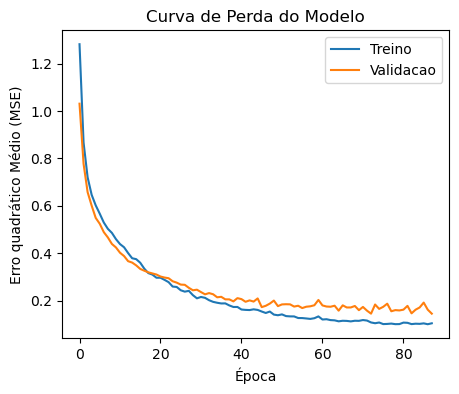

In [172]:
plt.figure(figsize=(5, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
#plt.yscale("log")
plt.xlabel("Época")
plt.legend(["Treino", "Validacao"])

## Predict

In [173]:
# Predição
y_pred_prob = model.predict(X_test_scaled)
y_pred_prob

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


array([[9.99429047e-01, 4.32614288e-05, 7.78369369e-09, 5.27690456e-04],
       [5.82476752e-03, 2.80328514e-03, 8.74906164e-06, 9.91363227e-01],
       [7.80461848e-01, 2.06290139e-03, 1.06772195e-05, 2.17464536e-01],
       ...,
       [4.18580556e-03, 9.94696975e-01, 1.53634687e-08, 1.11720641e-03],
       [1.03971668e-01, 8.96025419e-01, 2.33888201e-07, 2.69069847e-06],
       [7.03191012e-02, 8.47284775e-03, 2.54055522e-06, 9.21205521e-01]],
      shape=(1092, 4), dtype=float32)

In [174]:
# Pega a nota com maior probabilidade
y_pred = np.argmax(y_pred_prob, axis=1)
y_pred 

array([0, 3, 0, ..., 1, 1, 3], shape=(1092,))

## Avaliation

In [175]:
# Avaliação final
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nAcurácia final no teste: {accuracy * 100:.2f}%")

# Mostrando as classes que o modelo aprendeu a prever
print("\nClasses mapeadas:", dict(enumerate(encoder.classes_)))


Acurácia final no teste: 94.69%

Classes mapeadas: {0: 'Move-Forward', 1: 'Sharp-Right-Turn', 2: 'Slight-Left-Turn', 3: 'Slight-Right-Turn'}


In [176]:
print(f"Acurácia no teste: {accuracy_score(y_test, y_pred):.4f}\n")

print("Relatório de Classificação:\n", classification_report(y_test, y_pred, zero_division=0))


Acurácia no teste: 0.9469

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       441
           1       0.97      0.95      0.96       420
           2       0.91      0.94      0.93        66
           3       0.92      0.92      0.92       165

    accuracy                           0.95      1092
   macro avg       0.94      0.94      0.94      1092
weighted avg       0.95      0.95      0.95      1092



In [177]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:")
print(cm)

Matriz de confusão:
[[419  10   3   9]
 [ 12 401   3   4]
 [  2   2  62   0]
 [ 13   0   0 152]]


In [178]:
model.save("models/robo_posicao_webots.keras")